# Data Preprocessing with Scikit-learn and Pandas

**Course**: Data Science and Machine Learning for Engineering Applications  
**Politecnico di Torino - DataBase and Data Mining Group**

---

## Agenda

* **Part 1 - Missing values**
* **Part 2 - Normalization**  
* **Part 3 - Feature extraction** 
* **Part 4 - Dimensionality reduction (PCA)** 
* **Part 5 - Text preprocessing pipeline**  (not covered in powerpoint slides)


> **The golden rule - repeated throughout this notebook:**  
> *Fit all transformers only on training data. Never fit on test data.*

In [1]:
# Core imports - run this first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---
# Part 1 - Missing Values

Scikit-learn estimators are **incompatible with missing values** (e.g. `NaN`, blank entries). They assume that all values in an array are numerical and present.

Two strategies:
- **Discard** rows or columns that contain missing values
- **Impute** - replace missing values with a computed substitute (mean, median, constant, …)

## 1.1 Creating a DataFrame with missing values

In [2]:
data = np.array([[1,  2,  3,  4],
                 [5,  6,  7,  np.nan],
                 [9, 10, np.nan, 11]])

df = pd.DataFrame(data, columns=["A", "B", "C", "D"])
df

,A,B,C,D
0,1.0,2.0,3.0,4.0
1,5.0,6.0,7.0,NaN
2,9.0,10.0,NaN,11.0


## 1.2 Detecting missing values

`df.isnull()` returns a boolean mask: `True` where a value is missing.

In [3]:
df.isnull()

,A,B,C,D
0,False,False,False,False
1,False,False,False,True
2,False,False,True,False


In [4]:
# Count missing values per column
df.isnull().sum()

A    0
B    0
C    1
D    1
dtype: int64

## 1.3 Discarding missing values - `dropna()`

- `axis=0` removes **rows** that contain at least one `NaN`
- `axis=1` removes **columns** that contain at least one `NaN`

In [5]:
# Drop rows - only row 0 survives
df.dropna(axis=0)

,A,B,C,D
0,1.0,2.0,3.0,4.0


In [6]:
# Drop columns - only A and B survive
df.dropna(axis=1)

,A,B
0,1.0,2.0
1,5.0,6.0
2,9.0,10.0


In [ ]:
# Drop rows only where column D is missing
# Row 1 is removed (NaN in D). Row 2 stays - its NaN is in C, not D.
df.dropna(subset=["D"])

,A,B,C,D
0,1.0,2.0,3.0,4.0
1,5.0,6.0,7.0,NaN
2,9.0,10.0,NaN,11.0


In [11]:
# df is unchanged - dropna returns a new DataFrame
print(df)

# df=df.dropna()  # This would change df, but we won't do it here

     A     B    C     D
0  1.0   2.0  3.0   4.0
1  5.0   6.0  7.0   NaN
2  9.0  10.0  NaN  11.0


In [13]:
# Equivalent using boolean indexing
df[df["D"].notnull()]

,A,B,C,D
0,1.0,2.0,3.0,4.0
2,9.0,10.0,NaN,11.0


## 1.4 Imputing missing values

Dropping rows wastes data. **Imputation** replaces `NaN` with a reasonable estimate.

### Option A - Pandas `fillna()` (quick, returns a DataFrame)

In [24]:
print(df)
print(df.mean())

     A     B    C     D
0  1.0   2.0  3.0   4.0
1  5.0   6.0  7.0   NaN
2  9.0  10.0  NaN  11.0
A    5.0
B    6.0
C    5.0
D    7.5
dtype: float64


In [25]:
df.fillna(df.mean())

# df is unchanged - fillna returns a new DataFrame

,A,B,C,D
0,1.0,2.0,3.0,4.0
1,5.0,6.0,7.0,7.5
2,9.0,10.0,5.0,11.0


### Option B - Scikit-learn `SimpleImputer` (follows the fit/transform pattern)

Available `strategy` values: `'mean'`, `'median'`, `'most_frequent'`, `'constant'`.

> ⚠️ **Fit only on training data - then transform both train and test with the same statistics.**

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split


X_train,X_test = train_test_split(df, test_size=0.33, random_state=42) # Here you decide how many samples you want in the training and in the test set

imp = SimpleImputer(missing_values=np.nan, strategy='mean')

imp.fit(X_train.values)                       # learn column means from training data
X_train_imp = imp.transform(X_train.values)
# X_train_imp = imp.fit_transform(X_train.values)  # you can alternatively fit and transform in one step

X_test_imp  = imp.transform(X_test.values)    # same learned means - do NOT re-fit!

print("Imputed training set:")
print(X_train_imp)
# Note: SimpleImputer returns a NumPy array, not a DataFrame

Imputed training set:
[[ 5.  6.  7. 11.]
 [ 9. 10.  7. 11.]]


---
# Part 2 - Normalization

Features often live on very different scales (e.g. age vs. salary). Many ML algorithms are sensitive to this - especially distance-based (KNN) or gradient-based (neural networks) ones.

| Method | Formula | Output range |
|--------|---------|-------------|
| **Min-Max** (`MinMaxScaler`) | $(x - x_{\min}) / (x_{\max} - x_{\min})$ | $[0, 1]$ |
| **Z-score** (`StandardScaler`) | $(x - \mu) / \sigma$ | mean = 0, std = 1 |

In [31]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

X_train = [[0, 10],
           [0, 20],
           [2, 10],
           [2, 20]]
X_test = [[1, 15]]

minmax_s = MinMaxScaler()

# Correct workflow
minmax_s.fit(X_train)
X_train_norm = minmax_s.transform(X_train)
X_test_norm  = minmax_s.transform(X_test)       # apply training statistics to test

# Wrong workflow - shown here for comparison only
X_test_wrong = minmax_s.fit_transform(X_test)   # re-fitting on test leaks information!

print("Correct test result: ", X_test_norm)     # [[0.5  0.5]]  <- correct
print("Wrong test result:   ", X_test_wrong)    # [[0.   0. ]]  <- wrong

Correct test result:  [[0.5 0.5]]
Wrong test result:    [[0. 0.]]


When you call `fit_transform(X_test)`, the scaler recomputes min and max from the **test set alone**. With a single point `[1, 15]`, the min and max of each feature are the value itself, so everything maps to 0. The scaler no longer uses the scale it learned from training data.

In [32]:
# StandardScaler - same pattern
zscore_s = StandardScaler()
zscore_s.fit(X_train)
X_train_z = zscore_s.transform(X_train)
X_test_z  = zscore_s.transform(X_test)

print("Z-score normalised training set:\n", X_train_z)
print("Z-score normalised test point:  ", X_test_z)

Z-score normalised training set:
 [[-1. -1.]
 [-1.  1.]
 [ 1. -1.]
 [ 1.  1.]]
Z-score normalised test point:   [[0. 0.]]


### ALWAYS REMEMBER
> 1. **Fit** the transformer only on the training set
> 2. **Transform** the training set (`fit_transform()` is a shortcut for this step)
> 3. **Only transform** the test set - never fit on it!

---
# Part 3 - Feature Extraction

Feature extraction is necessary when data is **not in numerical vector form**: categorical labels, raw text, images, etc.

## 3.1 Nominal (categorical) data

Nominal values have **no natural ordering** - they can only be compared for equality.

**Integer encoding is wrong** for nominal data:
```
red -> 0,  green -> 1,  blue -> 2
```
The model would treat blue (2) as "twice" green (1) - a meaningless relationship.

**One-hot encoding is correct:**
```
red   -> [1, 0, 0]
green -> [0, 1, 0]
blue  -> [0, 0, 1]
```

> **Curse of dimensionality**: output size grows linearly with the number of distinct values. Distance-based models (KNN, clustering) struggle in very high-dimensional spaces.

### Option A - `DictVectorizer` (input: list of dicts)

In [39]:
from sklearn.feature_extraction import DictVectorizer

data = [
    {'model': 'a', 'price': 20000},
    {'model': 'b', 'price': 10000},
    {'model': 'b', 'price':  8000},

    {'model': 'a', 'price': 40000},

    {'model': 'c', 'price':  8500},
]

vect = DictVectorizer(sparse=False, dtype=int)
X_encoded = vect.fit_transform(data)

print("Feature names:", vect.get_feature_names_out())
print()
print(X_encoded)

Feature names: ['model=a' 'model=b' 'model=c' 'price']

[[    1     0     0 20000]
 [    0     1     0 10000]
 [    0     1     0  8000]
 [    1     0     0 40000]
 [    0     0     1  8500]]


The columns `model=a`, `model=b`, `model=c` are the one-hot components. The numerical `price` column is passed through as-is.

With a train/test split, fit only on training data:

In [41]:
train = data[:3]
test  = data[3:]

vect2 = DictVectorizer(sparse=False, dtype=int)
vect2.fit(train)                          # learn vocabulary from training set only
test_transformed = vect2.transform(test)

print("Test set transformed:")
print(test_transformed)

# The test set contains a new category 'model=c' that was not seen in training. 
# By default, DictVectorizer ignores it and produces a zero vector for the 'model' feature. This is a common approach to handle unseen categories at test time.
# without splitting beforehand, the model would have seen 'model=c' during fitting and would have created a feature for it. 
# Then, at test time, it would have expected that feature to be present, and the transformation would have worked without issues. 
# However, this would not reflect a realistic scenario where the model encounters new categories in production.


Test set transformed:
[[    1     0 40000]
 [    0     0  8500]]


### Option B - `OneHotEncoder` (input: feature matrix)

In [48]:
from sklearn.preprocessing import OneHotEncoder

X = np.array([
    ["a", 20000],
    ["b", 10000],
    ["c",  8000],
    ["a", 40000],
    ["c",  8500],
])

# OneHotEncoder encodes ALL columns if you pass the full matrix.
# We only want to encode column 0 (the categorical one).
ohe = OneHotEncoder(sparse_output=False, dtype=int)
X_ohe = ohe.fit_transform(X[:, :1])   # encode only column 0

# Combine the one-hot columns with the original numerical column
X_enc = np.hstack([X_ohe, X[:, 1:].astype(int)])
print(X_enc)

[[    1     0     0 20000]
 [    0     1     0 10000]
 [    0     0     1  8000]
 [    1     0     0 40000]
 [    0     0     1  8500]]


---
# Part 4 - Dimensionality Reduction (PCA)

When datasets have many features, reducing dimensionality can help:
- Visualise data in 2D/3D
- Reduce computational cost and noise
- Combat the **curse of dimensionality** (distances become meaningless in very high-dimensional spaces)

**PCA** finds the directions of maximum variance in the data and projects onto a lower-dimensional subspace.

> If you know linear algebra: PCA is a rotation along the eigenvectors of the covariance matrix.


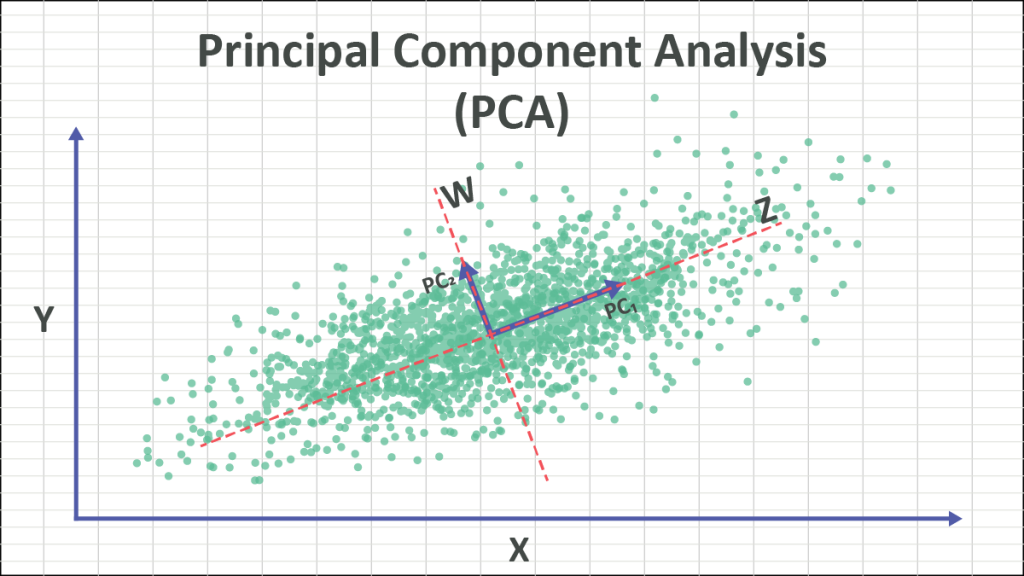

## 4.1 Basic PCA

In [50]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data
print(f"Original shape: {X_iris.shape}  ({X_iris.shape[1]} features)")

pca = PCA(n_components=2)
X_proj = pca.fit_transform(X_iris)
print(f"Projected shape: {X_proj.shape}")

Original shape: (150, 4)  (4 features)
Projected shape: (150, 2)


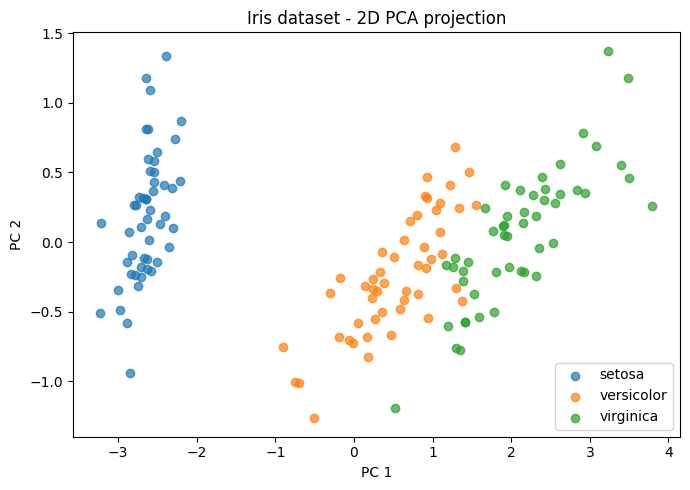

In [51]:
plt.figure(figsize=(7, 5))
for label, name in zip([0, 1, 2], iris.target_names):
    mask = iris.target == label
    plt.scatter(X_proj[mask, 0], X_proj[mask, 1], label=name, alpha=0.7)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("Iris dataset - 2D PCA projection")
plt.legend()
plt.tight_layout()
plt.show()

## 4.2 Choosing the number of components - cumulative explained variance

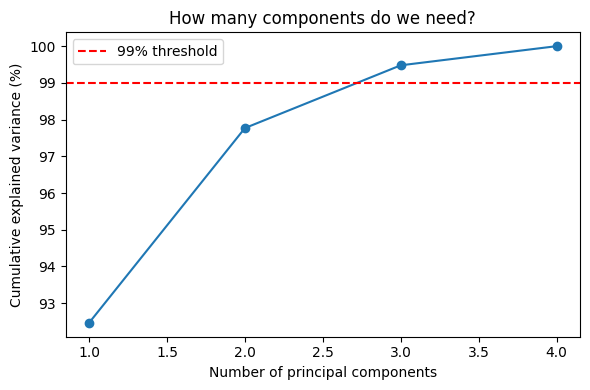

Components needed to reach 99% explained variance: 3


In [54]:
pca_full = PCA()
pca_full.fit(X_iris)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
threshold = 0.99 #Set your desired explained variance threshold here, for example 0.90 for 90%


plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cumvar) + 1), cumvar * 100, marker='o')
plt.axhline(threshold * 100, color='red', linestyle='--', label=f'{threshold * 100:.0f}% threshold')
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance (%)")
plt.title("How many components do we need?")
plt.legend()
plt.tight_layout()
plt.show()

n_needed = np.where(cumvar >= threshold)[0][0] + 1
print(f"Components needed to reach {threshold*100:.0f}% explained variance: {n_needed}")

## 4.3 Full pipeline: normalize -> PCA -> classify

The same rule applies to PCA as to scalers: fit on train, only transform test.

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 1 - Normalise BEFORE PCA
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Step 2 - PCA (fit on train only)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca  = pca.transform(X_test_s)      # do NOT re-fit!

# Step 3 - Train and evaluate
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_train_pca, y_train)
y_pred = clf.predict(X_test_pca)

print(f"Accuracy with 2 PCA components: {accuracy_score(y_test, y_pred):.2f}")

Accuracy with 2 PCA components: 0.96


### ALWAYS REMEMBER: Normalise before PCA!

PCA is sensitive to the scale of features. 

**Example: Think of a screw**: 
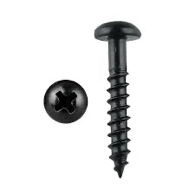
- its length is much greater than its diameter. 
- Without normalisation, PCA will orient the first principal component almost entirely along the length dimension - not because it is more informative, but only because its values are numerically larger.

> Always standardise (zero mean, unit variance) before applying PCA.

---
# Part 5 - Text Preprocessing Pipeline

We now build the complete pipeline from raw text to a TF-IDF representation, step by step:

```
1. Load and inspect the raw text
2. Clean (lowercase, remove noise)
3. Lemmatize
4. Bag of Words + Word Cloud
5. Stop words + TF-IDF + Word Cloud comparison
```

We work on a real `.txt` file - a book, collection of articles, or any corpus of your choice.

In [57]:
!pip install spacy wordcloud
!python -m spacy download en_core_web_sm

  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.0.5-py3-none-any.whl.metadata (23 kB)
  Using cached murmurhash-1.0.15-cp312-cp312-macosx_11_0_arm64.whl.metadata (2.3 kB)
  Using cached cymem-2.0.13-cp312-cp312-macosx_11_0_arm64.whl.metadata (9.7 kB)
  Using cached wasabi-1.1.3-py3-none-any.whl.metadata (28 kB)
  Using cached catalogue-2.0.10-py3-none-any.whl.metadata (14 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 8.3 MB/s eta 0:00:00
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.41.5-cp312-cp312-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached blis-1.3.3-cp312-cp312-macosx_11_

In [58]:
# Libraries for this section - install once if needed
# !pip install spacy wordcloud
# !python -m spacy download en_core_web_sm

import re
import spacy
from tqdm.notebook import tqdm
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("Ready.")

Ready.


## 5.1 Load the text

We read the file all at once with `.read()`, then split it into paragraphs using the double newline `\n\n` as separator - a common structure in plain-text books and articles.

In [59]:
# Change to your file path
file_path = "sample.txt"

with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()

print(f"Total characters: {len(text)}")
print("\nFirst 500 characters:")
print(text[:500])

Total characters: 89939

First 500 characters:
M r. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much. They were the last people you’d expect to be involved in anything strange or mysterious, because they just didn’t hold with such nonsense.

Mr. Dursley was the director of a firm called Grunnings, which made drills. He was a big, beefy man with hardly any neck, although he did have a very large mustache. Mrs. Dursley was thin and blonde and had nearly twice the usual amoun


In [60]:
# Split into paragraphs and strip whitespace
# We also drop empty strings that result from consecutive blank lines
raw_paragraphs = text.split(sep='\n\n')
paragraphs = [p.strip() for p in raw_paragraphs if p.strip() != ""]

print(f"Total paragraphs after stripping: {len(paragraphs)}")
print("\nFirst 3:")
for i, p in enumerate(paragraphs[:3]):
    print(f"[{i}] {p[:120]}...")

Total paragraphs after stripping: 537

First 3:
[0] M r. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very m...
[1] Mr. Dursley was the director of a firm called Grunnings, which made drills. He was a big, beefy man with hardly any neck...
[2] The Dursleys had everything they wanted, but they also had a secret, and their greatest fear was that somebody would dis...


### Why inspect paragraph lengths?

Very short "paragraphs" are often chapter headings, page numbers, or formatting noise - not real text. Keeping them would add meaningless entries to our corpus. Always look at the distribution before proceeding.

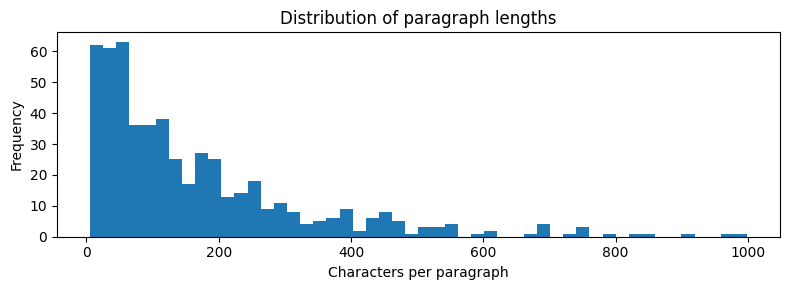

Min: 5  |  Max: 999  |  Median: 110


In [61]:
lengths = [len(p) for p in paragraphs]

plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=50)
plt.xlabel("Characters per paragraph")
plt.ylabel("Frequency")
plt.title("Distribution of paragraph lengths")
plt.tight_layout()
plt.show()

print(f"Min: {min(lengths)}  |  Max: {max(lengths)}  |  Median: {int(np.median(lengths))}")

In [66]:
for p in paragraphs:
    if len(p) < 10:
        print(f"Short paragraph ({len(p)} chars): {p[:100]}...")

Short paragraph (9 chars): “A what?”...
Short paragraph (5 chars): * * *...
Short paragraph (6 chars): Surrey...
Short paragraph (7 chars): “But —”...
Short paragraph (5 chars): * * *...
Short paragraph (7 chars): Room 17...
Short paragraph (9 chars): Cokeworth...
Short paragraph (5 chars): * * *...
Short paragraph (5 chars): BOOM....
Short paragraph (6 chars): SMASH!...
Short paragraph (6 chars): Hagrid...
Short paragraph (6 chars): “Who?”...
Short paragraph (7 chars): “What?”...
Short paragraph (8 chars): “Knuts?”...


In [67]:
# Keep only paragraphs with at least 50 characters
min_length = 50
filtered = [p for p in paragraphs if len(p) >= min_length]

print(f"Paragraphs kept: {len(filtered)}  (removed {len(paragraphs) - len(filtered)})")

Paragraphs kept: 400  (removed 137)


## 5.2 Text cleaning

Each cleaning rule is a deliberate **modeling choice**: what you discard depends on your task.

| Rule | What it removes |
|------|-----------------|
| Lowercase | Case variation (`NLP` and `nlp` become the same token) |
| Remove URLs | `http://...`, `www....` |
| Remove mentions | `@username` |
| Remove non-alphabetic chars | Digits, punctuation |
| Collapse whitespace | Multiple spaces/newlines |

We use Python's `re` module. `re.sub(pattern, replacement, string)` replaces all occurrences of `pattern` with `replacement`.

In [ ]:
def clean_text(text: str) -> str:
    text = text.lower()                              # lowercase
    text = re.sub(r"http\S+|www\.\S+", "", text)    # remove URLs
    text = re.sub(r"@\w+", "", text)                 # remove @mentions
    text = re.sub(r"[^a-z\s]", "", text)             # keep only letters and spaces
    text = re.sub(r"\s+", " ", text).strip()         # collapse multiple spaces
    return text



Before: M r. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very m

After:  m r and mrs dursley of number four privet drive were proud to say that they were perfectly normal thank you very much th


In [76]:
tweets=pd.read_csv("twitter.csv")["Tweet Content"]
tweets

0      Pets change our lives &amp; become a part of o...
1      Another spot of our #morethanmedicine bus in #...
2      What a great team ⁦@HealthSourceOH⁩ ⁦@Local12⁩...
3      What a great team ⁦@HealthSourceOH⁩ ⁦@Local12⁩...
4      What a great team ⁦@HealthSourceOH⁩ ⁦@Local12⁩...
                             ...                        
381    #MorethanMedicine What does this mean? 🤔\nBy p...
382    After a great weekend at #rebellion19 we are b...
383    #MorethanMedicine What does this mean? 🤔\nBy p...
384    #MorethanMedicine What does this mean? 🤔\nBy p...
385    #MorethanMedicine What does this mean? 🤔\nBy p...
Name: Tweet Content, Length: 386, dtype: str

In [75]:
tweets.map(clean_text)

# print("Before:", tweets[1][:120])
# print()
# print("After: ", tweets_clean[0][:120])

0      pets change our lives amp become a part of our...
1      another spot of our morethanmedicine bus in br...
2                     what a great team morethanmedicine
3                     what a great team morethanmedicine
4                     what a great team morethanmedicine
                             ...                        
381    morethanmedicine what does this mean by protec...
382    after a great weekend at rebellion we are back...
383    morethanmedicine what does this mean by protec...
384    morethanmedicine what does this mean by protec...
385    morethanmedicine what does this mean by protec...
Name: Tweet Content, Length: 386, dtype: str

In [77]:
sentences_clean = [clean_text(p) for p in filtered]


## 5.3 Lemmatization

Words like `run`, `running`, and `ran` all refer to the same concept. **Lemmatization** maps each token to its canonical dictionary form (its *lemma*) using linguistic knowledge about morphology.

```
running  ->  run
studies  ->  study
children ->  child
```

We use **spaCy**, which performs tokenization and lemmatization in one step.

> When lemmatization is too slow on very large corpora, a faster alternative is **stemming**: it cuts word endings using heuristic rules (`studies -> studi`). Faster, but the output is not always a real word, and it ignores context (part of speech).

In [79]:
nlp = spacy.load("en_core_web_sm")

lemmatized_sentences = []

for s in sentences_clean:
    doc = nlp(s)
    lemmas = [token.lemma_ for token in doc]
    lemmatized_sentences.append(" ".join(lemmas))

# Compare before and after for the first paragraph
print("Before:", sentences_clean[0][:120])
print("After: ", lemmatized_sentences[0][:120])

Before: m r and mrs dursley of number four privet drive were proud to say that they were perfectly normal thank you very much th
After:  m r and mrs dursley of number four privet drive be proud to say that they be perfectly normal thank you very much they b


In [81]:
! pip install nltk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 10.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.6/289.6 kB 12.2 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [83]:
# Stemming alternative - shown for comparison
from nltk.stem.snowball import SnowballStemmer
import nltk
nltk.download('punkt', quiet=True)

stemmer = SnowballStemmer("english")

stemmed_sentences = []
for s in sentences_clean:
    stems = [stemmer.stem(w) for w in s.split()]
    stemmed_sentences.append(" ".join(stems))

print("Stemmed: ", stemmed_sentences[0][:120])

Stemmed:  m r and mrs dursley of number four privet drive were proud to say that they were perfect normal thank you veri much they


In [84]:
# Side-by-side: stemming vs lemmatization on a few words
test_words = ["running", "studies", "children", "quickly", "better", "models"]

print(f"{'Word':12s}  {'Lemma (spaCy)':16s}  {'Stem (Snowball)'}")
print("-" * 46)
for w in test_words:
    lemma = nlp(w)[0].lemma_
    stem  = stemmer.stem(w)
    print(f"{w:12s}  {lemma:16s}  {stem}")

Word          Lemma (spaCy)     Stem (Snowball)
----------------------------------------------
running       run               run
studies       study             studi
children      child             children
quickly       quickly           quick
better        well              better
models        model             model


## 5.4 Bag of Words

We convert the lemmatized text into a count matrix using `CountVectorizer`:
- Rows = documents
- Columns = words in the vocabulary
- Values = how many times each word appears in each document

The matrix is **sparse** - each document contains only a tiny fraction of all vocabulary words.

In [85]:
# Quick sanity check
print(f"Documents to vectorize: {len(lemmatized_sentences)}")
print(f"\nExample:\n{lemmatized_sentences[0]}")

Documents to vectorize: 400

Example:
m r and mrs dursley of number four privet drive be proud to say that they be perfectly normal thank you very much they be the last people you d expect to be involve in anything strange or mysterious because they just do not hold with such nonsense


In [86]:
bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(lemmatized_sentences)

vocab = bow_vectorizer.get_feature_names_out()
print(f"Vocabulary size: {len(vocab)} unique words")
print(f"Matrix shape: {X_bow.shape}  (documents x words)")

Vocabulary size: 2036 unique words
Matrix shape: (400, 2036)  (documents x words)


In [87]:
# Sample of the vocabulary
print(vocab[:30])

['able' 'abnormal' 'aboard' 'abou' 'about' 'above' 'accept' 'across' 'act'
 'actually' 'address' 'admire' 'adventure' 'affect' 'afraid' 'after'
 'afternoon' 'afterward' 'again' 'against' 'age' 'ago' 'agree' 'ah' 'air'
 'airplane' 'alarm' 'albus' 'alien' 'alive']


In [88]:
# Inspect the first document - print only words that actually appear in it
first_doc_bow = X_bow[0].toarray().flatten()
present_idx   = np.where(first_doc_bow >= 1)[0]

print("Words in document 0:")
for idx in present_idx:
    print(f"  {vocab[idx]:20s}: {int(first_doc_bow[idx])}")

Words in document 0:
  and                 : 1
  anything            : 1
  be                  : 4
  because             : 1
  do                  : 1
  drive               : 1
  dursley             : 1
  expect              : 1
  four                : 1
  hold                : 1
  in                  : 1
  involve             : 1
  just                : 1
  last                : 1
  mrs                 : 1
  much                : 1
  mysterious          : 1
  nonsense            : 1
  normal              : 1
  not                 : 1
  number              : 1
  of                  : 1
  or                  : 1
  people              : 1
  perfectly           : 1
  privet              : 1
  proud               : 1
  say                 : 1
  strange             : 1
  such                : 1
  thank               : 1
  that                : 1
  the                 : 1
  they                : 3
  to                  : 2
  very                : 1
  with                : 1
  you            

Exception ignored in: <function tqdm.__del__ at 0x1510058a0>
Traceback (most recent call last):
  File "/Users/giordanopaoletti/Desktop/Laboratori/ds-ml-engineering-labs/.venv/lib/python3.12/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/Users/giordanopaoletti/Desktop/Laboratori/ds-ml-engineering-labs/.venv/lib/python3.12/site-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


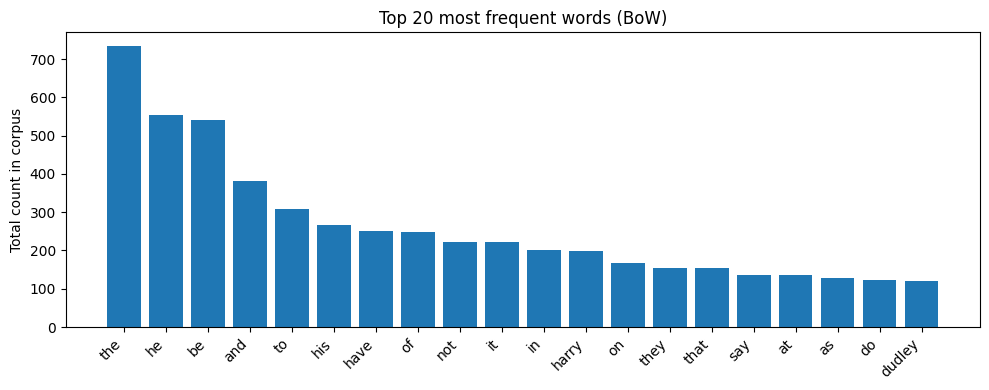

In [89]:
# Most frequent words across the entire corpus
word_counts = np.asarray(X_bow.sum(axis=0)).flatten()
top_n   = 20
top_idx = word_counts.argsort()[::-1][:top_n]
top_words  = vocab[top_idx]
top_counts = word_counts[top_idx]

plt.figure(figsize=(10, 4))
plt.bar(top_words, top_counts)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total count in corpus")
plt.title(f"Top {top_n} most frequent words (BoW)")
plt.tight_layout()
plt.show()

Before moving on, inspect the chart:
- Do the top words make sense for your text?
- Are there obvious noise tokens that slipped through cleaning?
- Do function words (`the`, `and`, `is`, ...) dominate?

BoW loses word order and syntax, but for many tasks it is still a strong baseline.

## 5.4.1 Word Cloud from BoW counts

A word cloud visualises word frequencies: the larger the word, the more frequent it is. It is not a rigorous analytical tool, but it is a fast way to identify dominant terms - and spot noise.

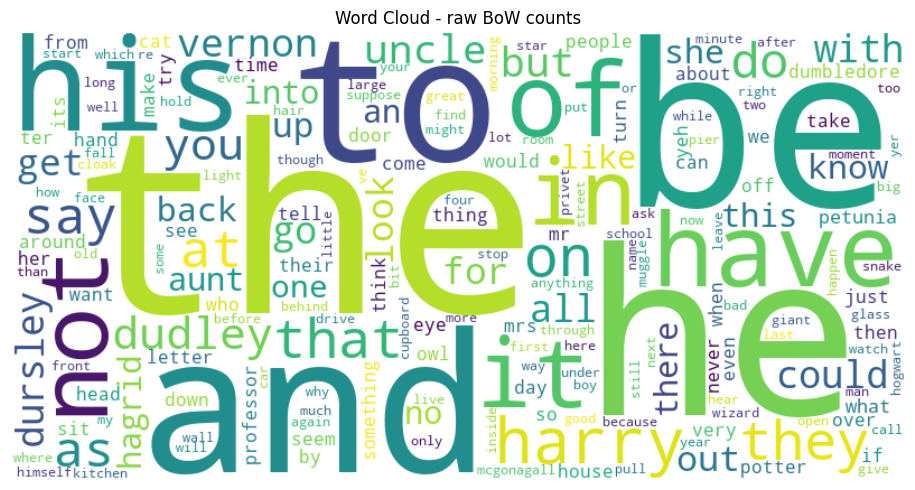

In [90]:
word_freq = dict(zip(vocab, word_counts))

wc_bow = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate_from_frequencies(word_freq)

plt.figure(figsize=(12, 5))
plt.imshow(wc_bow, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - raw BoW counts")
plt.tight_layout()
plt.show()

### Expected observation

Very common, low-information words likely dominate: `the`, `and`, `is`, `of`, `he`, `said`, ...  
These are **stop words**. They appear in virtually every document and carry little discriminating information.  
This motivates the next step: removing stop words and weighting by TF-IDF instead of raw counts.

## 5.5 Stop words + TF-IDF

**Guiding question: are the most frequent words the most informative ones?**

Almost never.

**Stop words** are common words that:
- appear in almost every document
- carry little discriminating meaning on their own

`TfidfVectorizer` handles stop words and TF-IDF weighting together:
- `stop_words="english"` removes a built-in English stop word list
- `max_df=0.9` also removes words that appear in more than 90% of documents (corpus-specific common words)
- `min_df=0.01` removes words that appear in fewer than 1% of documents (rare noise)

In [91]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.9,
    min_df=0.01,
)

X_tfidf = tfidf_vectorizer.fit_transform(lemmatized_sentences)

tfidf_vocab = tfidf_vectorizer.get_feature_names_out()
print(f"Vocabulary size after stop word filtering: {len(tfidf_vocab)}  (was {len(vocab)})")

Vocabulary size after stop word filtering: 389  (was 2036)


In [92]:
# Aggregate TF-IDF scores across the corpus
tfidf_scores = np.asarray(X_tfidf.sum(axis=0)).flatten()

top_n = 20
top_idx_tfidf    = tfidf_scores.argsort()[::-1][:top_n]
top_tfidf_words  = tfidf_vocab[top_idx_tfidf]
top_tfidf_scores = tfidf_scores[top_idx_tfidf]

list(zip(top_tfidf_words, top_tfidf_scores.round(2)))[:10]

[('harry', np.float64(27.01)),
 ('say', np.float64(25.12)),
 ('uncle', np.float64(18.73)),
 ('vernon', np.float64(18.68)),
 ('dudley', np.float64(18.2)),
 ('look', np.float64(14.07)),
 ('hagrid', np.float64(12.91)),
 ('dursley', np.float64(12.56)),
 ('know', np.float64(12.54)),
 ('like', np.float64(10.89))]

## 5.5.1 Word Cloud from TF-IDF weights

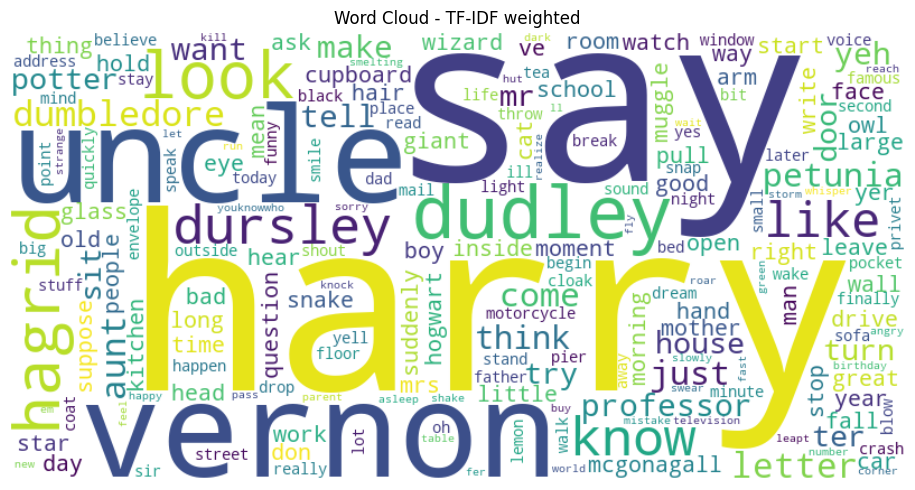

In [93]:
tfidf_freq = dict(zip(tfidf_vocab, tfidf_scores))

wc_tfidf = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate_from_frequencies(tfidf_freq)

plt.figure(figsize=(12, 5))
plt.imshow(wc_tfidf, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - TF-IDF weighted")
plt.tight_layout()
plt.show()

## 5.5.2 Side-by-side comparison

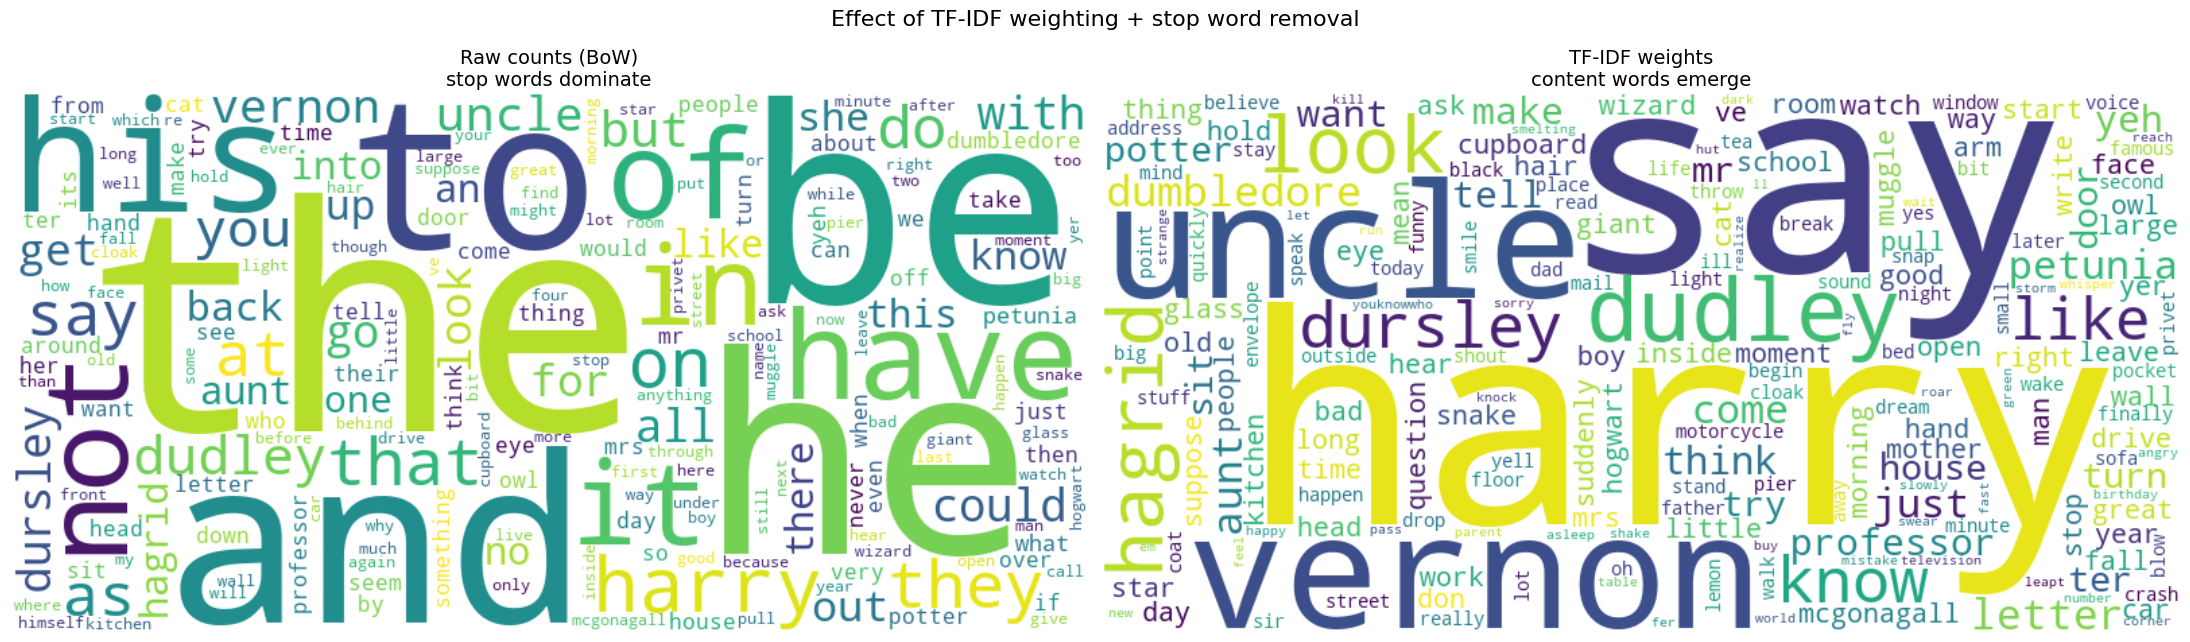

In [94]:
fig, axes = plt.subplots(ncols=2, figsize=(22, 7))

axes[0].imshow(wc_bow, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Raw counts (BoW)\nstop words dominate", fontsize=14)

axes[1].imshow(wc_tfidf, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("TF-IDF weights\ncontent words emerge", fontsize=14)

plt.suptitle("Effect of TF-IDF weighting + stop word removal", fontsize=16)
plt.tight_layout()
plt.show()

### What usually changes

- Stop words shrink or disappear entirely
- More specific, content-bearing words become prominent
- The cloud becomes easier to interpret

This difference comes entirely from **weighting and filtering** - not from changing any of the underlying text.

---

## Part 5 recap - full text preprocessing pipeline

| Step | Tool | What it does |
|------|------|--------------|
| Load & split | `open()`, `str.split('\\n\\n')` | Raw text -> paragraph list |
| Length filter | list comprehension | Remove short formatting artifacts |
| Clean | `re.sub()` | Remove URLs, mentions, non-alphabetic chars |
| Lemmatize | `spaCy` | Reduce words to base form |
| BoW | `CountVectorizer` | Word count matrix |
| Word Cloud (counts) | `WordCloud` | Visual inspection of raw frequencies |
| TF-IDF | `TfidfVectorizer(stop_words, max_df, min_df)` | Importance-weighted matrix |
| Word Cloud (TF-IDF) | `WordCloud` | Improved visual inspection |

The final `X_tfidf` matrix is a standard numerical feature matrix - it can be passed directly to any Scikit-learn classifier, clustering algorithm, or the `PCA` from Part 4.